# 03 — Exploratory Data Analysis
Before building any model, we explore the data to understand patterns, spot issues, and form hypotheses about what drives Mets attendance.

Unlike the Padres (who sell out nearly every game), the Mets have significant attendance variance — ranging from ~15k to 42k. This makes for a more interesting and informative model.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

TEAM_ID = 121  # New York Mets
SEASONS = [2022, 2023, 2024, 2025]

df = pd.read_csv("../data/mets_master.csv")
df["date"] = pd.to_datetime(df["date"])

# Drop Final games with no reported attendance (mostly doubleheader game-2s)
n_before = len(df)
df = df.dropna(subset=["attendance"]).reset_index(drop=True)
print(f"Dropped {n_before - len(df)} games with missing attendance")

df["attendance"] = df["attendance"].astype(int)

print(f"Shape: {df.shape}")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")
df.head()

Dropped 9 games with missing attendance
Shape: (311, 32)
Date range: 2022-04-15 to 2025-09-21


,date,season,opponent,home_score,away_score,attendance,status,game_pk,avg_temp_f,avg_precip_mm,...,mets_streak_num,opp_streak_num,mets_games_back,opp_games_back,mets_starter_name,mets_starter_era,opp_starter_name,opp_starter_era,starter_era_diff,mets_starter_is_ace
0,2022-04-15,2022,Arizona Diamondbacks,10.0,3.0,43820,Final,662485,56.5,0.0,...,3,-1.0,0.0,3.0,Chris Bassitt,0.00,Zach Davies,3.60,3.60,1
1,2022-04-16,2022,Arizona Diamondbacks,2.0,3.0,37935,Final,662626,56.7,0.0,...,-1,1.0,0.0,3.0,Carlos Carrasco,1.59,Zac Gallen,NaN,NaN,1
2,2022-04-17,2022,Arizona Diamondbacks,5.0,0.0,24515,Final,662625,48.1,0.0,...,1,-1.0,0.0,4.0,David Peterson,NaN,Humberto Castellanos,NaN,NaN,0
3,2022-04-19,2022,San Francisco Giants,3.0,1.0,27490,Final,662616,49.6,0.0,...,3,-2.0,0.0,1.0,Max Scherzer,3.27,Logan Webb,1.29,-1.98,0
4,2022-04-20,2022,San Francisco Giants,2.0,5.0,30050,Final,662349,53.7,0.0,...,-1,1.0,0.0,1.0,Chris Bassitt,0.75,Carlos Rodón,1.50,0.75,1


## Data Quality Check

In [2]:
print("Missing values:")
print(df.isnull().sum())
print()
print("Attendance summary:")
print(df["attendance"].describe().round(0))

Missing values:
date                     0
season                   0
opponent                 0
home_score               0
away_score               0
attendance               0
status                   0
game_pk                  0
avg_temp_f               0
avg_precip_mm            0
n_promotions             0
is_promo                 0
is_bobblehead            0
promotion_names        211
mets_wins                0
opp_wins                 3
mets_losses              0
opp_losses               3
mets_win_pct             0
opp_win_pct              3
mets_streak_code         0
opp_streak_code          3
mets_streak_num          0
opp_streak_num           3
mets_games_back          0
opp_games_back           3
mets_starter_name        0
mets_starter_era        15
opp_starter_name         0
opp_starter_era         18
starter_era_diff        27
mets_starter_is_ace      0
dtype: int64

Attendance summary:
count      311.0
mean     33876.0
std       6900.0
min      15020.0
25%      28514.0
5

## Attendance Distribution
How spread out is attendance? Is it normally distributed or skewed?

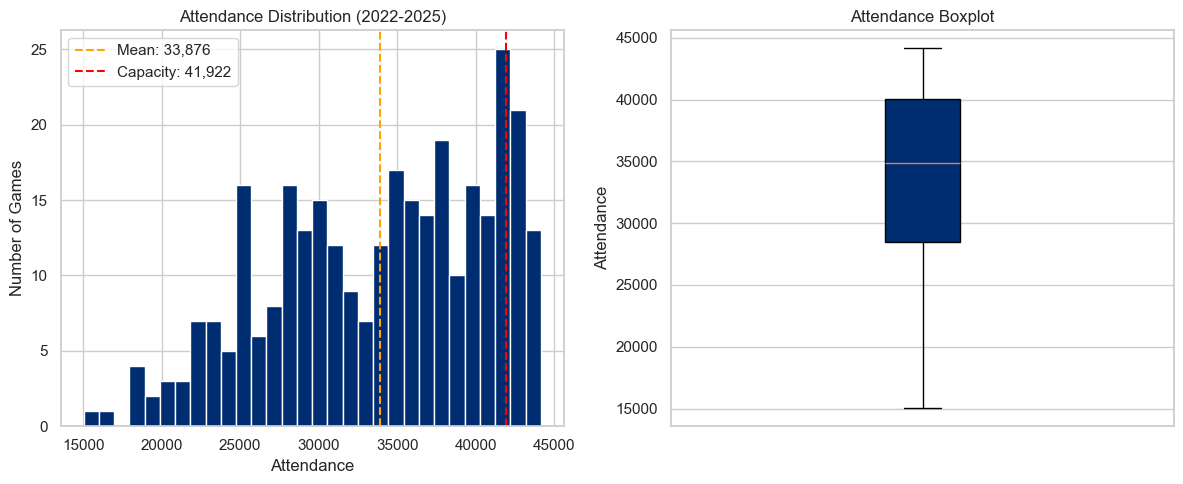

In [3]:
CAPACITY = 41922  # Citi Field official capacity

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(df["attendance"], bins=30, color="#002D72", edgecolor="white")
axes[0].axvline(df["attendance"].mean(), color="orange", linestyle="--", label=f"Mean: {df['attendance'].mean():,.0f}")
axes[0].axvline(CAPACITY, color="red", linestyle="--", label=f"Capacity: {CAPACITY:,}")
axes[0].set_xlabel("Attendance")
axes[0].set_ylabel("Number of Games")
axes[0].set_title("Attendance Distribution (2022-2025)")
axes[0].legend()

axes[1].boxplot(df["attendance"], patch_artist=True, boxprops=dict(facecolor="#002D72"))
axes[1].set_ylabel("Attendance")
axes[1].set_title("Attendance Boxplot")
axes[1].set_xticks([])

plt.tight_layout()
plt.show()

## Attendance by Season

         mean  median    min    max
season                             
2022    33308   33630  22007  43857
2023    33069   33779  20191  44121
2024    29172   28864  15020  44152
2025    39776   41162  28630  43945


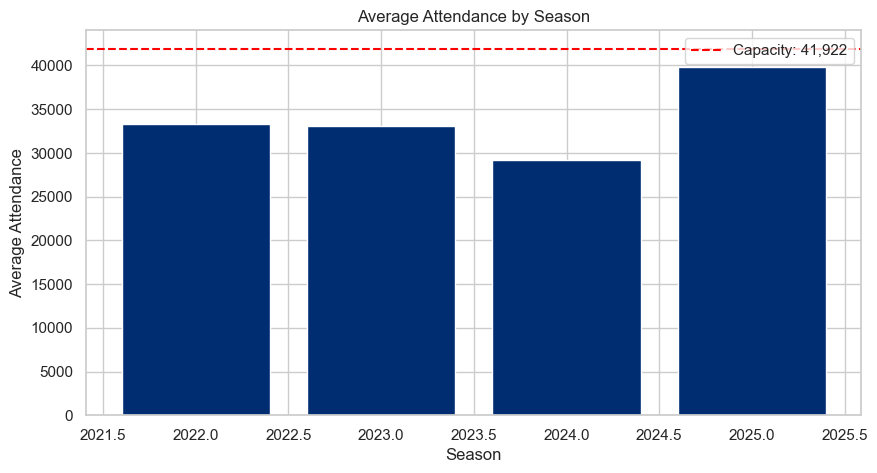

In [4]:
season_stats = df.groupby("season")["attendance"].agg(["mean", "median", "min", "max"]).round(0).astype(int)
print(season_stats)

season_means = df.groupby("season")["attendance"].mean()
plt.bar(season_means.index, season_means.values, color="#002D72", edgecolor="white")
plt.axhline(CAPACITY, color="red", linestyle="--", label=f"Capacity: {CAPACITY:,}")
plt.xlabel("Season")
plt.ylabel("Average Attendance")
plt.title("Average Attendance by Season")
plt.legend()
plt.show()

## Attendance by Day of Week

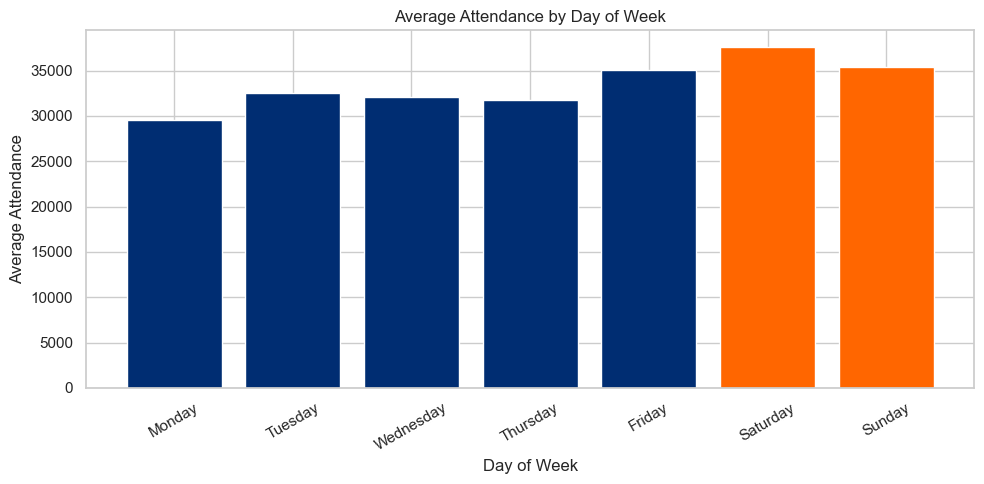

day_of_week
Monday       29577
Tuesday      32586
Wednesday    32105
Thursday     31747
Friday       35094
Saturday     37559
Sunday       35347
Name: attendance, dtype: int64


In [5]:
df["day_of_week"] = df["date"].dt.day_name()
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

day_avg = df.groupby("day_of_week")["attendance"].mean().reindex(day_order)

colors = ["#002D72" if d not in ["Saturday", "Sunday"] else "#FF6600" for d in day_order]
plt.bar(day_avg.index, day_avg.values, color=colors, edgecolor="white")
plt.xlabel("Day of Week")
plt.ylabel("Average Attendance")
plt.title("Average Attendance by Day of Week")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

print(day_avg.round(0).astype(int))

## Attendance by Month
New York weather makes month a much stronger signal than for San Diego — cold April games and hot summer games are meaningfully different.

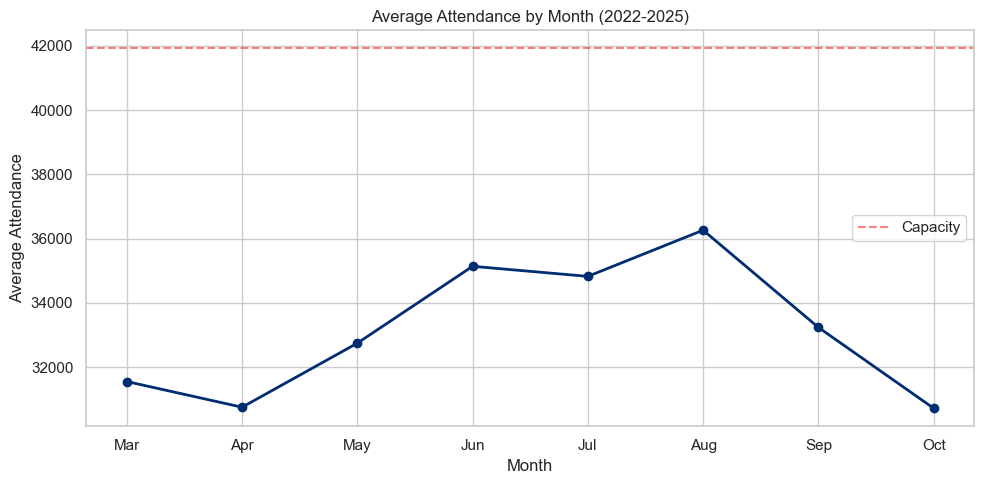

In [6]:
df["month"] = df["date"].dt.month
month_names = {3: "Mar", 4: "Apr", 5: "May", 6: "Jun", 7: "Jul", 8: "Aug", 9: "Sep", 10: "Oct"}

month_avg = df.groupby("month")["attendance"].mean()
month_avg.index = month_avg.index.map(month_names)

plt.plot(month_avg.index, month_avg.values, marker="o", color="#002D72", linewidth=2)
plt.axhline(CAPACITY, color="red", linestyle="--", alpha=0.5, label="Capacity")
plt.xlabel("Month")
plt.ylabel("Average Attendance")
plt.title("Average Attendance by Month (2022-2025)")
plt.legend()
plt.tight_layout()
plt.show()

## Top and Bottom Opponents by Attendance

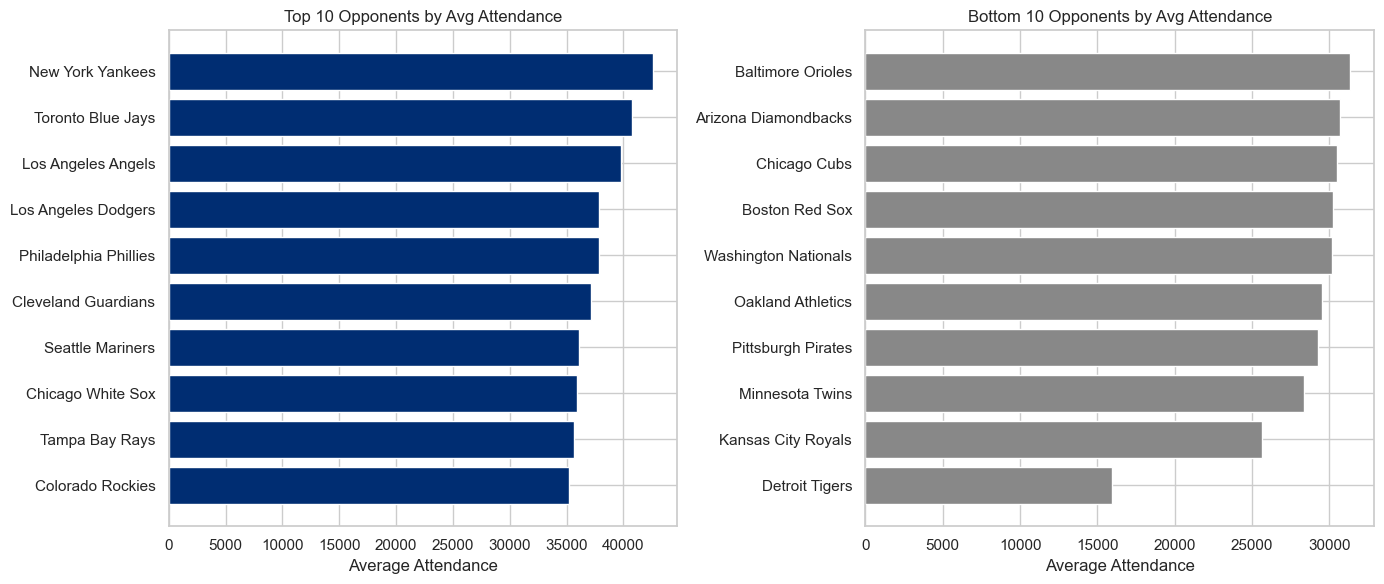

In [7]:
opponent_avg = df.groupby("opponent")["attendance"].mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

top10 = opponent_avg.head(10)
axes[0].barh(top10.index[::-1], top10.values[::-1], color="#002D72")
axes[0].set_title("Top 10 Opponents by Avg Attendance")
axes[0].set_xlabel("Average Attendance")

bot10 = opponent_avg.tail(10)
axes[1].barh(bot10.index[::-1], bot10.values[::-1], color="#888")
axes[1].set_title("Bottom 10 Opponents by Avg Attendance")
axes[1].set_xlabel("Average Attendance")

plt.tight_layout()
plt.show()

## Weather vs. Attendance
Unlike San Diego, New York weather is a real variable — cold April/May games and rain should show meaningful effects here.

Temperature — Linear R²:    0.0693
Temperature — Quadratic R²: 0.0697
Temperature — Quadratic peak (vertex): 166.9F
Precipitation — Linear R²:    0.0152
Precipitation — Quadratic R²: 0.0152


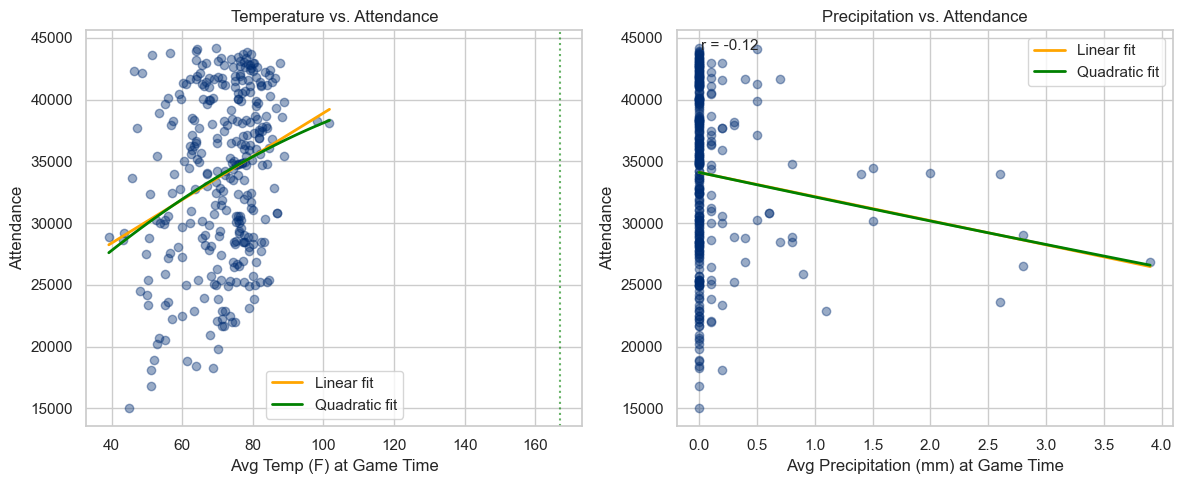

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

def r_squared(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)
    return 1 - ss_res / ss_tot

weather = df.dropna(subset=["avg_temp_f"])
x = weather["avg_temp_f"]
y = weather["attendance"]

axes[0].scatter(x, y, alpha=0.4, color="#002D72")

x_line = np.linspace(x.min(), x.max(), 100)

# Linear fit
lin_coefs = np.polyfit(x, y, 1)
lin_fit = np.poly1d(lin_coefs)
axes[0].plot(x_line, lin_fit(x_line), color="orange", linewidth=2, label="Linear fit")

# Quadratic fit — attendance likely peaks at a comfortable temp and drops off
# toward both cold and hot extremes, so a curve should fit better than a line
quad_coefs = np.polyfit(x, y, 2)
quad_fit = np.poly1d(quad_coefs)
axes[0].plot(x_line, quad_fit(x_line), color="green", linewidth=2, label="Quadratic fit")

peak_temp = -quad_coefs[1] / (2 * quad_coefs[0])
axes[0].axvline(peak_temp, color="green", linestyle=":", alpha=0.6)

axes[0].set_xlabel("Avg Temp (F) at Game Time")
axes[0].set_ylabel("Attendance")
axes[0].set_title("Temperature vs. Attendance")
axes[0].legend()

r2_lin = r_squared(y, lin_fit(x))
r2_quad = r_squared(y, quad_fit(x))
print(f"Temperature — Linear R²:    {r2_lin:.4f}")
print(f"Temperature — Quadratic R²: {r2_quad:.4f}")
print(f"Temperature — Quadratic peak (vertex): {peak_temp:.1f}F")

# Precipitation vs attendance, with linear and quadratic fits
px = df["avg_precip_mm"]
py = df["attendance"]

axes[1].scatter(px, py, alpha=0.4, color="#002D72")

px_line = np.linspace(px.min(), px.max(), 100)

precip_lin_coefs = np.polyfit(px, py, 1)
precip_lin_fit = np.poly1d(precip_lin_coefs)
axes[1].plot(px_line, precip_lin_fit(px_line), color="orange", linewidth=2, label="Linear fit")

precip_quad_coefs = np.polyfit(px, py, 2)
precip_quad_fit = np.poly1d(precip_quad_coefs)
axes[1].plot(px_line, precip_quad_fit(px_line), color="green", linewidth=2, label="Quadratic fit")

axes[1].set_xlabel("Avg Precipitation (mm) at Game Time")
axes[1].set_ylabel("Attendance")
axes[1].set_title("Precipitation vs. Attendance")
corr_precip = df[["avg_precip_mm", "attendance"]].corr().iloc[0, 1]
axes[1].text(0.05, 0.95, f"r = {corr_precip:.2f}", transform=axes[1].transAxes, fontsize=11)
axes[1].legend()

r2_precip_lin = r_squared(py, precip_lin_fit(px))
r2_precip_quad = r_squared(py, precip_quad_fit(px))
print(f"Precipitation — Linear R²:    {r2_precip_lin:.4f}")
print(f"Precipitation — Quadratic R²: {r2_precip_quad:.4f}")

plt.tight_layout()
plt.show()

## Correlation Summary

Correlation with attendance:
               attendance
is_weekend          0.312
dayofweek           0.298
avg_temp_f          0.263
season              0.258
month               0.154
avg_precip_mm      -0.123


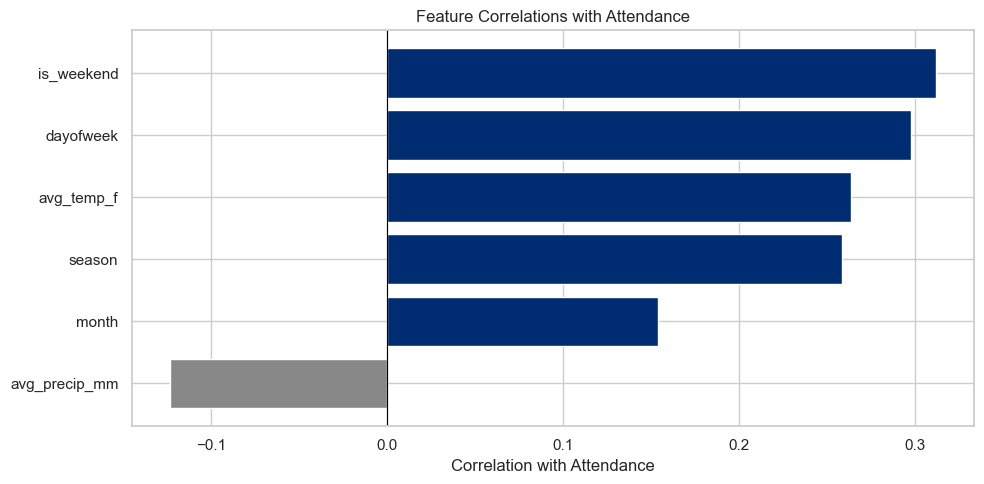

In [9]:
df["dayofweek"] = df["date"].dt.dayofweek
df["is_weekend"] = df["dayofweek"].isin([4, 5, 6]).astype(int)

numeric_cols = ["attendance", "season", "month", "dayofweek", "is_weekend", "avg_temp_f", "avg_precip_mm"]
corr = df[numeric_cols].corr()[["attendance"]].drop("attendance").sort_values("attendance", ascending=False)

print("Correlation with attendance:")
print(corr.round(3))

colors = ["#002D72" if v > 0 else "#888" for v in corr["attendance"].values[::-1]]
plt.barh(corr.index[::-1], corr["attendance"].values[::-1], color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Correlation with Attendance")
plt.title("Feature Correlations with Attendance")
plt.tight_layout()
plt.show()

## Correlation Summary Excluding Marquee Opponents
Some opponents (Yankees Subway Series, Blue Jays, Angels, Dodgers) draw near-capacity crowds almost regardless of day, month, or weather. That ceiling effect can drown out the signal from other features — check whether correlations strengthen once those games are excluded.

Marquee opponents (avg attendance > 39,000):
opponent
New York Yankees      42605
Toronto Blue Jays     40714
Los Angeles Angels    39765
Name: attendance, dtype: int64

Excluded 21 games, 290 remain

Correlation with attendance — all games vs. excluding marquee opponents:
               all_games  excl_marquee  abs_change
is_weekend         0.312         0.341       0.030
dayofweek          0.298         0.331       0.033
avg_temp_f         0.263         0.259      -0.004
season             0.258         0.255      -0.003
month              0.154         0.175       0.021
avg_precip_mm     -0.123        -0.114      -0.009


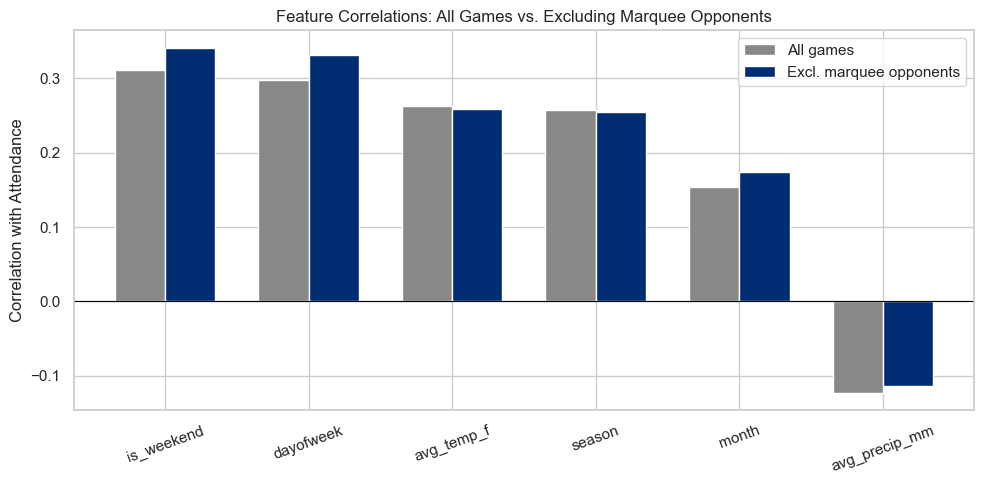

In [10]:
# Marquee opponents that draw near-capacity crowds regardless of day/month/weather
MARQUEE_THRESHOLD = 39000  # ~93% of Citi Field capacity
opp_avg = df.groupby("opponent")["attendance"].mean()
marquee_opponents = opp_avg[opp_avg > MARQUEE_THRESHOLD].sort_values(ascending=False)
print("Marquee opponents (avg attendance > {:,}):".format(MARQUEE_THRESHOLD))
print(marquee_opponents.round(0).astype(int))

df_no_marquee = df[~df["opponent"].isin(marquee_opponents.index)].copy()
print(f"\nExcluded {len(df) - len(df_no_marquee)} games, {len(df_no_marquee)} remain")

corr_full = df[numeric_cols].corr()[["attendance"]].drop("attendance").rename(columns={"attendance": "all_games"})
corr_no_marquee = df_no_marquee[numeric_cols].corr()[["attendance"]].drop("attendance").rename(columns={"attendance": "excl_marquee"})
comparison = corr_full.join(corr_no_marquee)
comparison["abs_change"] = (comparison["excl_marquee"].abs() - comparison["all_games"].abs()).round(3)
comparison = comparison.sort_values("all_games", ascending=False)

print("\nCorrelation with attendance — all games vs. excluding marquee opponents:")
print(comparison.round(3))

x = np.arange(len(comparison))
width = 0.35
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width / 2, comparison["all_games"], width, label="All games", color="#888")
ax.bar(x + width / 2, comparison["excl_marquee"], width, label="Excl. marquee opponents", color="#002D72")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(comparison.index, rotation=20)
ax.set_ylabel("Correlation with Attendance")
ax.set_title("Feature Correlations: All Games vs. Excluding Marquee Opponents")
ax.legend()
plt.tight_layout()
plt.show()

## Game Time: Day Games vs. Night Games

In [11]:
def get_game_times(team_id, seasons):
    times = {}
    for season in seasons:
        url = "https://statsapi.mlb.com/api/v1/schedule"
        params = {"sportId": 1, "season": season, "gameType": "R",
                  "teamId": team_id, "hydrate": "linescore,team"}
        data = requests.get(url, params=params).json()
        for date in data.get("dates", []):
            for game in date.get("games", []):
                if game["teams"]["home"]["team"]["id"] == team_id:
                    game_dt_str = game.get("gameDate", "")
                    if game_dt_str:
                        dt = pd.to_datetime(game_dt_str, utc=True)
                        # Convert UTC to Eastern (UTC-4 during baseball season / EDT)
                        hour_et = (dt.hour - 4) % 24
                        minute_et = dt.minute
                        times[game["gamePk"]] = hour_et + minute_et / 60
    return times

print("Fetching game times...")
game_times = get_game_times(TEAM_ID, SEASONS)
df["game_hour_et"] = df["game_pk"].map(game_times)
df["is_day_game"] = (df["game_hour_et"] < 17).astype(int)

print(f"Day games:   {df['is_day_game'].sum()}")
print(f"Night games: {(df['is_day_game'] == 0).sum()}")
print()
print("Most common start hours (ET):")
print(df["game_hour_et"].round(1).value_counts().sort_index())

Fetching game times...
Day games:   124
Night games: 187

Most common start hours (ET):
game_hour_et
12.1      3
12.2      1
13.2     34
13.7     41
15.2      6
16.1      2
16.2     37
17.2      1
18.7      1
19.1      3
19.2    181
19.3      1
Name: count, dtype: int64


In [12]:
def time_bucket(hour):
    if hour < 17:
        return "Early (<5pm)"
    elif hour < 18.5:
        return "Twilight (5-6:30pm)"
    else:
        return "Night (6:30pm+)"

df["time_bucket"] = df["game_hour_et"].apply(time_bucket)

print("Games per time bucket:")
print(df["time_bucket"].value_counts())
print()
print("Average attendance per time bucket:")
print(df.groupby("time_bucket")["attendance"].mean().round(0).astype(int))

Games per time bucket:
time_bucket
Night (6:30pm+)        186
Early (<5pm)           124
Twilight (5-6:30pm)      1
Name: count, dtype: int64

Average attendance per time bucket:
time_bucket
Early (<5pm)           34884
Night (6:30pm+)        33199
Twilight (5-6:30pm)    34805
Name: attendance, dtype: int64


Weekday average attendance by time bucket:
time_bucket  Early (<5pm)  Twilight (5-6:30pm)  Night (6:30pm+)
day_of_week                                                    
Monday              34163                 <NA>            29026
Tuesday             28676                 <NA>            33271
Wednesday           30807                 <NA>            32858
Thursday            30422                 <NA>            32838
Friday              42942                 <NA>            34241



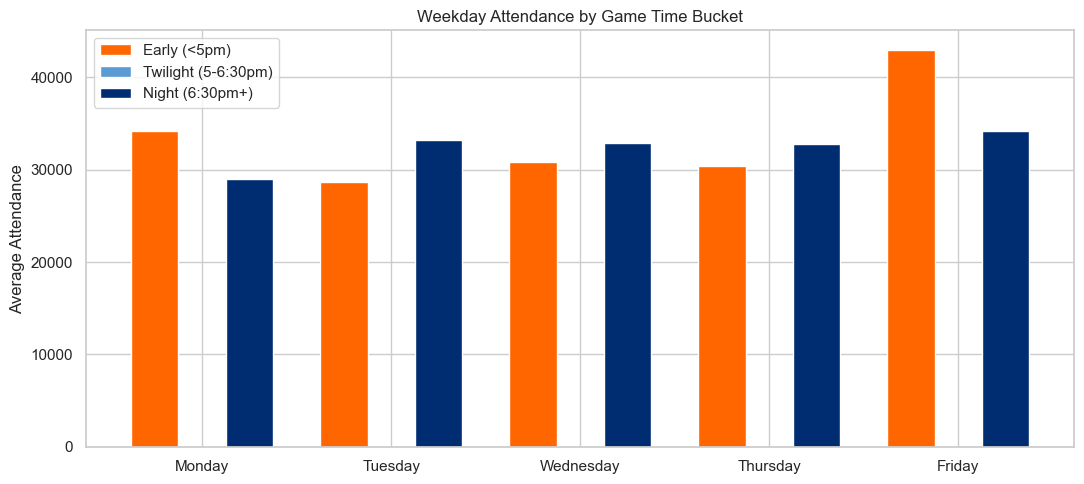

In [13]:
# Weekday-only breakdown by time bucket
weekdays = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday"]
wd = df[df["day_of_week"].isin(weekdays)].copy()

bucket_order = ["Early (<5pm)", "Twilight (5-6:30pm)", "Night (6:30pm+)"]
pivot = wd.groupby(["day_of_week", "time_bucket"])["attendance"].mean().unstack()
pivot = pivot.reindex(index=weekdays, columns=bucket_order)

print("Weekday average attendance by time bucket:")
print(pivot.round(0).astype("Int64"))
print()

x = np.arange(len(weekdays))
width = 0.25
colors = ["#FF6600", "#5B9BD5", "#002D72"]
fig, ax = plt.subplots(figsize=(11, 5))
for i, (bucket, color) in enumerate(zip(bucket_order, colors)):
    vals = pivot[bucket].fillna(0)
    ax.bar(x + (i - 1) * width, vals, width, label=bucket, color=color)
ax.set_xticks(x)
ax.set_xticklabels(weekdays)
ax.set_ylabel("Average Attendance")
ax.set_title("Weekday Attendance by Game Time Bucket")
ax.legend()
plt.tight_layout()
plt.show()

In [14]:
# Full day/time breakdown including weekends
all_days = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
bucket_order = ["Early (<5pm)", "Twilight (5-6:30pm)", "Night (6:30pm+)"]

avg_pivot = df.groupby(["day_of_week", "time_bucket"])["attendance"].mean().unstack().reindex(index=all_days, columns=bucket_order)
count_pivot = df.groupby(["day_of_week", "time_bucket"])["attendance"].count().unstack().reindex(index=all_days, columns=bucket_order)

print("Average attendance (n=game count):")
for day in all_days:
    row_parts = []
    for bucket in bucket_order:
        avg = avg_pivot.loc[day, bucket]
        cnt = count_pivot.loc[day, bucket]
        if pd.isna(avg):
            row_parts.append(f"{bucket[:6]}: ---")
        else:
            flag = " *" if cnt < 5 else ""
            row_parts.append(f"{bucket[:6]}: {int(avg):,} (n={int(cnt)}){flag}")
    print(f"{day:<12} | " + " | ".join(row_parts))

print()
print("* = fewer than 5 games, treat with caution")

Average attendance (n=game count):
Monday       | Early : 34,162 (n=3) * | Twilig: --- | Night : 29,026 (n=25)
Tuesday      | Early : 28,675 (n=7) | Twilig: --- | Night : 33,270 (n=40)
Wednesday    | Early : 30,807 (n=18) | Twilig: --- | Night : 32,857 (n=31)
Thursday     | Early : 30,421 (n=14) | Twilig: --- | Night : 32,837 (n=17)
Friday       | Early : 42,941 (n=5) | Twilig: --- | Night : 34,240 (n=46)
Saturday     | Early : 37,693 (n=35) | Twilig: --- | Night : 37,295 (n=18)
Sunday       | Early : 35,904 (n=42) | Twilig: 34,805 (n=1) * | Night : 32,807 (n=9)

* = fewer than 5 games, treat with caution


## National Broadcasts

In [15]:
def get_national_broadcasts(team_id, seasons):
    national = {}
    national_networks = {}
    for season in seasons:
        url = "https://statsapi.mlb.com/api/v1/schedule"
        params = {"sportId": 1, "season": season, "gameType": "R",
                  "teamId": team_id, "hydrate": "broadcasts"}
        data = requests.get(url, params=params).json()
        for date in data.get("dates", []):
            for game in date.get("games", []):
                if game["teams"]["home"]["team"]["id"] == team_id:
                    pk = game["gamePk"]
                    tv_national = [b["name"] for b in game.get("broadcasts", [])
                                   if b.get("type") == "TV" and b.get("isNational")]
                    national[pk] = 1 if tv_national else 0
                    national_networks[pk] = ", ".join(tv_national) if tv_national else None
    return national, national_networks

nat_flags, nat_networks = get_national_broadcasts(TEAM_ID, SEASONS)
df["is_national"] = df["game_pk"].map(nat_flags).fillna(0).astype(int)
df["national_network"] = df["game_pk"].map(nat_networks)

premium_networks = {"FOX", "FOX, FOX", "ESPN/ESPN App", "ESPN/ESPN App, ESPN/ESPN App",
                    "Apple TV", "Apple TV, Apple TV", "TBS (out-of-market only)",
                    "TBS (out-of-market only), TBS (out-of-market only)",
                    "TBS (out-of-market only), TBS", "Roku", "Roku, Roku",
                    "FS1", "FS1, FS1"}
df["is_premium_national"] = df["national_network"].isin(premium_networks).astype(int)

print(f"National broadcast games: {df['is_national'].sum()} / {len(df)}")
print()
print("By network:")
print(df[df["national_network"].notna()]["national_network"].value_counts())
print()
print("Average attendance by broadcast tier:")
tier_map = {(0, 0): "Non-national", (1, 0): "MLBN only", (1, 1): "Premium national"}
df["broadcast_tier"] = list(zip(df["is_national"], df["is_premium_national"]))
df["broadcast_tier"] = df["broadcast_tier"].map(tier_map)
print(df.groupby("broadcast_tier")["attendance"].mean().round(0).astype(int))

National broadcast games: 130 / 311

By network:
national_network
MLBN (out-of-market only), MLBN (out-of-market only)    73
ESPN/ESPN App, ESPN/ESPN App                            11
FOX, FOX                                                 9
Apple TV, Apple TV                                       8
FS1, FS1                                                 6
TBS, TBS                                                 5
MLBN, MLBN                                               5
TBS (out-of-market only), TBS (out-of-market only)       5
TBS, TBS (out-of-market only)                            3
MLBN (out-of-market only)                                2
Roku, Roku                                               2
NBCSN / Peacock, NBCSN / Peacock                         1
Name: count, dtype: int64

Average attendance by broadcast tier:
broadcast_tier
MLBN only           34725
Non-national        33038
Premium national    35733
Name: attendance, dtype: int64


## Promotional Events
`is_promo`/`is_bobblehead` come from `mets_promotions.csv` — hand-compiled from MLB.com press releases and fan sites (2022-2026), not an automated scrape. See the summary at the end of this notebook for exactly how it was built and its known gaps.

             mean  count
No Promo  32494.0    211
Promo     36792.0    100

                  mean  count
No Bobblehead  33341.0    280
Bobblehead     38705.0     31


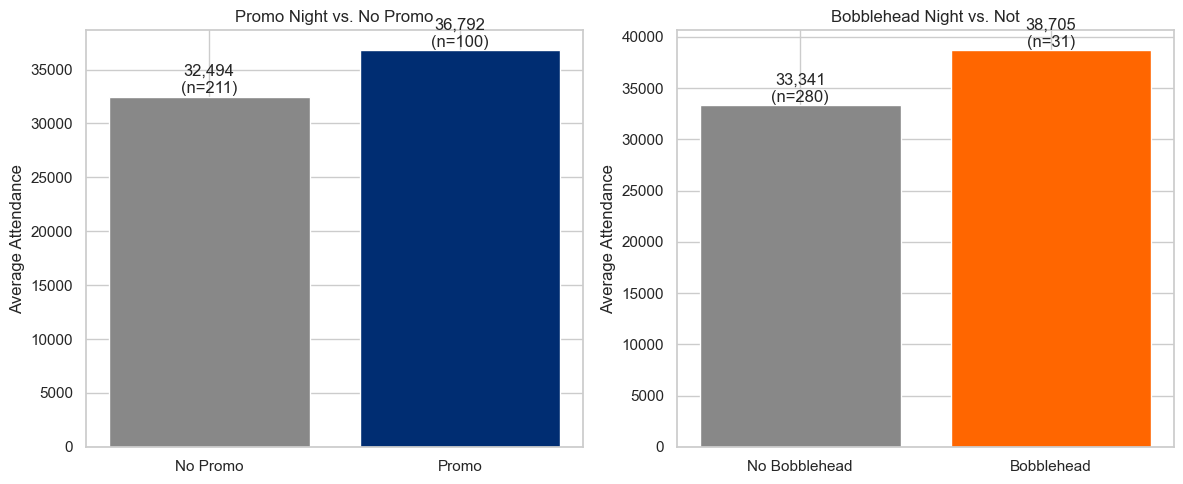

In [16]:
promo_stats = df.groupby("is_promo")["attendance"].agg(["mean", "count"]).round(0)
promo_stats.index = ["No Promo", "Promo"]
print(promo_stats)
print()

bh_stats = df.groupby("is_bobblehead")["attendance"].agg(["mean", "count"]).round(0)
bh_stats.index = ["No Bobblehead", "Bobblehead"]
print(bh_stats)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(promo_stats.index, promo_stats["mean"], color=["#888", "#002D72"])
for i, v in enumerate(promo_stats["mean"]):
    axes[0].text(i, v + 300, f"{v:,.0f}\n(n={int(promo_stats['count'].iloc[i])})", ha="center")
axes[0].set_ylabel("Average Attendance")
axes[0].set_title("Promo Night vs. No Promo")

axes[1].bar(bh_stats.index, bh_stats["mean"], color=["#888", "#FF6600"])
for i, v in enumerate(bh_stats["mean"]):
    axes[1].text(i, v + 300, f"{v:,.0f}\n(n={int(bh_stats['count'].iloc[i])})", ha="center")
axes[1].set_ylabel("Average Attendance")
axes[1].set_title("Bobblehead Night vs. Not")

plt.tight_layout()
plt.show()

## Team Performance: Win %, Games Back, Streak
`mets_win_pct`, `mets_games_back`, `mets_streak_num` come from the MLB Stats API standings endpoint queried per game date — a real API, not hand-compiled. Details on the exact calculation are in the summary at the end.

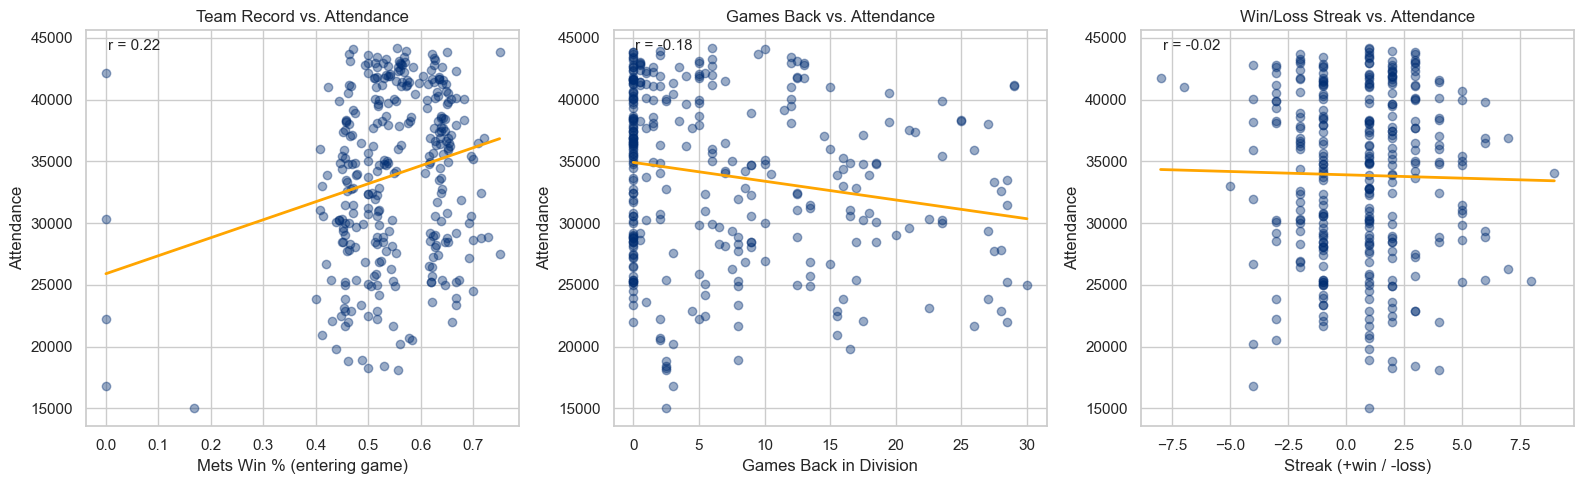

In [17]:
def scatter_with_fit(ax, x_col, y_col="attendance", color="#002D72"):
    data = df.dropna(subset=[x_col])
    x, y = data[x_col], data[y_col]
    ax.scatter(x, y, alpha=0.4, color=color)
    z = np.polyfit(x, y, 1)
    p = np.poly1d(z)
    x_line = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_line, p(x_line), color="orange", linewidth=2)
    corr = data[[x_col, y_col]].corr().iloc[0, 1]
    ax.text(0.05, 0.95, f"r = {corr:.2f}", transform=ax.transAxes, fontsize=11)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

scatter_with_fit(axes[0], "mets_win_pct")
axes[0].set_xlabel("Mets Win % (entering game)")
axes[0].set_ylabel("Attendance")
axes[0].set_title("Team Record vs. Attendance")

scatter_with_fit(axes[1], "mets_games_back")
axes[1].set_xlabel("Games Back in Division")
axes[1].set_ylabel("Attendance")
axes[1].set_title("Games Back vs. Attendance")

scatter_with_fit(axes[2], "mets_streak_num")
axes[2].set_xlabel("Streak (+win / -loss)")
axes[2].set_ylabel("Attendance")
axes[2].set_title("Win/Loss Streak vs. Attendance")

plt.tight_layout()
plt.show()

## Starting Pitcher ERA
`mets_starter_era` is each starter's ERA *entering* the game (computed from their prior starts that season only, not full-season/after-the-fact ERA). `ACE_ERA_THRESHOLD` is a placeholder cutoff — adjust once you've settled on what counts as "stellar."

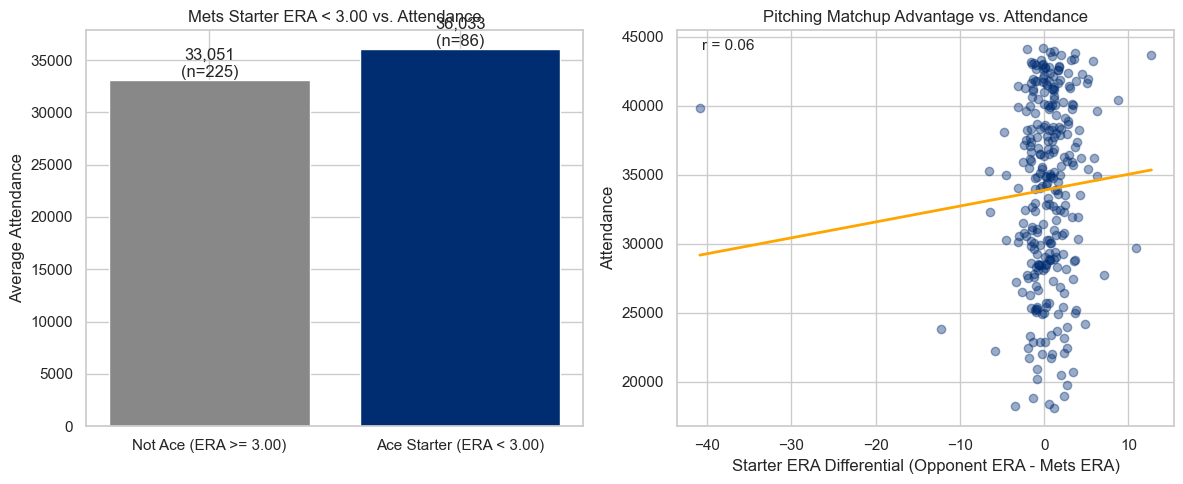

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ace_stats = df.groupby("mets_starter_is_ace")["attendance"].agg(["mean", "count"]).round(0)
ace_stats.index = ["Not Ace (ERA >= 3.00)", "Ace Starter (ERA < 3.00)"]
axes[0].bar(ace_stats.index, ace_stats["mean"], color=["#888", "#002D72"])
for i, v in enumerate(ace_stats["mean"]):
    axes[0].text(i, v + 300, f"{v:,.0f}\n(n={int(ace_stats['count'].iloc[i])})", ha="center")
axes[0].set_ylabel("Average Attendance")
axes[0].set_title("Mets Starter ERA < 3.00 vs. Attendance")

scatter_with_fit(axes[1], "starter_era_diff")
axes[1].set_xlabel("Starter ERA Differential (Opponent ERA - Mets ERA)")
axes[1].set_ylabel("Attendance")
axes[1].set_title("Pitching Matchup Advantage vs. Attendance")

plt.tight_layout()
plt.show()

## Full Correlation Summary (All Features)

Correlation with attendance, strongest first:
                     attendance
is_weekend                0.312
dayofweek                 0.298
is_promo                  0.291
n_promotions              0.282
avg_temp_f                0.263
season                    0.258
is_bobblehead             0.233
mets_win_pct              0.219
mets_games_back          -0.182
month                     0.154
is_national               0.144
avg_precip_mm            -0.123
is_day_game               0.119
is_premium_national       0.105
starter_era_diff          0.060
opp_games_back           -0.060
opp_starter_era           0.053
opp_win_pct              -0.052
mets_starter_era         -0.045
opp_streak_num           -0.032
mets_streak_num          -0.020


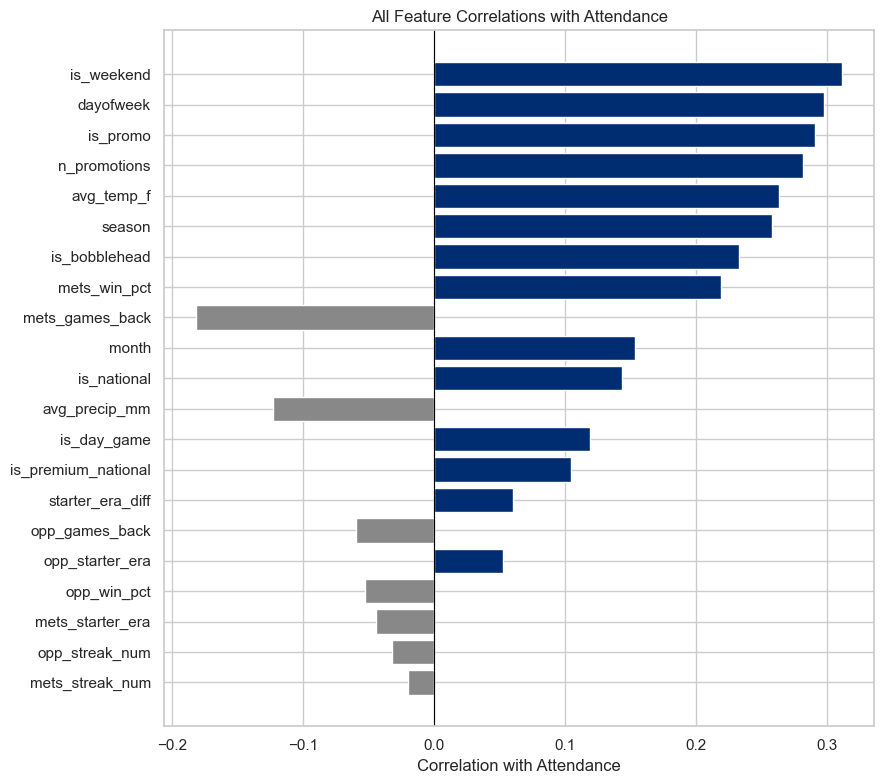

In [19]:
all_numeric_cols = [
    "attendance", "season", "month", "dayofweek", "is_weekend", "avg_temp_f", "avg_precip_mm",
    "is_promo", "is_bobblehead", "n_promotions",
    "mets_win_pct", "opp_win_pct", "mets_games_back", "opp_games_back", "mets_streak_num", "opp_streak_num",
    "mets_starter_era", "opp_starter_era", "starter_era_diff",
    "is_national", "is_premium_national", "is_day_game",
]
corr_all = df[all_numeric_cols].corr()[["attendance"]].drop("attendance")
corr_all = corr_all.reindex(corr_all["attendance"].abs().sort_values(ascending=False).index)

print("Correlation with attendance, strongest first:")
print(corr_all.round(3))

colors = ["#002D72" if v > 0 else "#888" for v in corr_all["attendance"].values[::-1]]
plt.figure(figsize=(9, 8))
plt.barh(corr_all.index[::-1], corr_all["attendance"].values[::-1], color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Correlation with Attendance")
plt.title("All Feature Correlations with Attendance")
plt.tight_layout()
plt.show()

## Data Provenance & Methodology Summary

**Games & attendance** — MLB Stats API `schedule` endpoint (home games only). Missing attendance values backfilled from the per-game `boxscore` endpoint. 3 neutral-site games (London/Mexico City) manually excluded. Rows with no attendance at all (mostly doubleheader game-2s) are dropped before analysis (9 of 320).

**Weather** — Open-Meteo archive API, one call per unique game date, averaging temperature/precipitation over 4pm-8pm local time (approximate game-time window, not the exact first pitch).

**Promotions (`is_promo`, `is_bobblehead`, `n_promotions`)** — **Hand-compiled, not an automated scrape.** No official API for historical promo schedules exists. Sources per season:
- 2022: stadiumgiveawayexchange.com (13 dates, mostly bobbleheads)
- 2023: official MLB.com press release (full schedule — giveaways + theme nights + fireworks + Hall of Fame ceremony)
- 2024: official Mets promotional schedule graphic (user-supplied image, full schedule)
- 2025: user-supplied article text (29 dates) + supplemented with a TickPick blog listing for late-July through September dates it covered that the first source didn't
- 2026: MLB.com "initial gate giveaway schedule" press release (partial — only the first half of the season is announced so far)

Known limitations: 2022 and 2024 press coverage is thinner than 2023/2025, so smaller giveaways may be missing; one date discrepancy exists in the 2025 data (a Francisco Lindor bobblehead is listed on both Aug 30 and Sep 17 by two different sources — kept both rather than guessing which is wrong). Treat this as a reasonable approximation, not a complete record. Raw data lives in `mets_promotions.csv` if you want to audit it directly.

**Team standings (`mets_win_pct`, `mets_games_back`, `mets_streak_num`, and opponent equivalents)** — MLB Stats API `standings` endpoint, queried once per unique date (covering both AL and NL to handle interleague opponents), pulling each team's cumulative record/streak/division-games-back as reported for that date. Note: it's a real API and not hand-compiled, but there's a small ambiguity in whether "as of date X" reflects the record entering that day or including that day's own result — treated as an approximation of "entering game day."

**Starting pitcher ERA (`mets_starter_era`, `opp_starter_era`, `starter_era_diff`)** — Probable starters pulled via the `schedule` endpoint's `probablePitcher` hydrate. ERA is **not** season-end ERA — it's calculated from each pitcher's `gameLog` by summing earned runs and innings pitched only from starts *strictly before* that game's date within that season, so it reflects what a ticket buyer would have seen going into that specific game. First starts of the season have no prior data and are `NaN` (17 of 320 games). `ACE_ERA_THRESHOLD = 3.00` in `02b_standings_and_pitchers.ipynb` is a placeholder — swap in whatever cutoff you settle on.

**A bug we caught and fixed along the way:** the first pass at pulling probable pitchers double-counted postponed/suspended games (listed once under the original date, once under the makeup date, each with different pitcher data for the same `game_pk`), which inflated the merged dataset from 320 to 334 rows. Caught by checking row counts and duplicate `game_pk`s after the merge; fixed by deduplicating on `game_pk` (keeping the later-dated listing) and rebuilding `mets_master.csv` from scratch. Final file is verified at 320 rows with zero duplicate `game_pk`s.